<a href="https://colab.research.google.com/github/dhag/colab_test/blob/main/Pose_Mediapipe_Tasks_API_latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MediaPipe Tasks API 最新版対応

旧 `mp.solutions.pose`、`mp.solutions.face_mesh`、`mp.solutions.holistic` を使用せず、最新版の **MediaPipe Tasks API / HolisticLandmarker** を使用する。

このノートブックでは次を行う。

- MP4動画から姿勢・顔・左右の手を検出して描画する
- 静止画像またはColab上のWebカメラ画像を処理する
- ランドマークをCSV・Excelへ保存する
- Colab上で録画したWebMをMP4へ変換し、同じ処理へ渡す

> `DATAID="mediapipe.solutions.holistic"` は、既存の受信側との互換性のため文字列だけ維持している。実際の検出APIは `HolisticLandmarker` である。


## 1. インストール


In [1]:
# Google Colab用
!pip install -q --upgrade mediapipe opencv-python-headless pandas openpyxl


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


## 2. 初期化・モデル取得・共通関数


In [2]:
import urllib.request
from pathlib import Path
from types import SimpleNamespace

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("MediaPipe version:", mp.__version__)

if not hasattr(vision, "HolisticLandmarker"):
    raise RuntimeError(
        "このMediaPipeにはHolisticLandmarkerが含まれていない。"
        "ランタイムを再起動して、インストールセルから実行し直すこと。"
    )

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "holistic_landmarker/holistic_landmarker/float16/latest/"
    "holistic_landmarker.task"
)
MODEL_PATH = Path("holistic_landmarker.task")

if not MODEL_PATH.exists():
    print("モデルをダウンロード中...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

print("Model:", MODEL_PATH.resolve())

# 既存システムとの互換性を維持する識別情報
config = SimpleNamespace(
    HOST="127.0.0.1",
    PORT=58576,
    DATAID="mediapipe.solutions.holistic",
    UID="ID0",
    TimeStamp="",
)


MediaPipe version: 1.0.0
モデルをダウンロード中...
Model: /content/holistic_landmarker.task


In [3]:
DrawingSpec = vision.drawing_utils.DrawingSpec

POSE_CONNECTIONS = vision.PoseLandmarksConnections.POSE_LANDMARKS
HAND_CONNECTIONS = vision.HandLandmarksConnections.HAND_CONNECTIONS
FACE_CONNECTIONS = vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS

POSE_POINT_SPEC = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2)
POSE_LINE_SPEC = DrawingSpec(color=(255, 255, 255), thickness=2)
HAND_POINT_SPEC = DrawingSpec(color=(0, 255, 255), thickness=2, circle_radius=2)
HAND_LINE_SPEC = DrawingSpec(color=(0, 255, 0), thickness=2)
FACE_LINE_SPEC = DrawingSpec(color=(255, 255, 0), thickness=1)


def create_holistic_landmarker(running_mode):
    # IMAGE / VIDEOモードのHolisticLandmarkerを生成する。
    options = vision.HolisticLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
        running_mode=running_mode,
        min_face_detection_confidence=0.5,
        min_face_landmarks_confidence=0.5,
        min_pose_detection_confidence=0.5,
        min_pose_landmarks_confidence=0.5,
        min_hand_landmarks_confidence=0.5,
        output_face_blendshapes=False,
        output_segmentation_mask=False,
    )
    return vision.HolisticLandmarker.create_from_options(options)


def bgr_to_mp_image(image_bgr):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)


def annotate_holistic(image_bgr, result):
    annotated = image_bgr.copy()

    if result.face_landmarks:
        vision.drawing_utils.draw_landmarks(
            annotated,
            result.face_landmarks,
            FACE_CONNECTIONS,
            landmark_drawing_spec=None,
            connection_drawing_spec=FACE_LINE_SPEC,
        )

    if result.pose_landmarks:
        vision.drawing_utils.draw_landmarks(
            annotated,
            result.pose_landmarks,
            POSE_CONNECTIONS,
            landmark_drawing_spec=POSE_POINT_SPEC,
            connection_drawing_spec=POSE_LINE_SPEC,
        )

    if result.left_hand_landmarks:
        vision.drawing_utils.draw_landmarks(
            annotated,
            result.left_hand_landmarks,
            HAND_CONNECTIONS,
            landmark_drawing_spec=HAND_POINT_SPEC,
            connection_drawing_spec=HAND_LINE_SPEC,
        )

    if result.right_hand_landmarks:
        vision.drawing_utils.draw_landmarks(
            annotated,
            result.right_hand_landmarks,
            HAND_CONNECTIONS,
            landmark_drawing_spec=HAND_POINT_SPEC,
            connection_drawing_spec=HAND_LINE_SPEC,
        )

    return annotated


def detection_summary(result):
    return {
        "pose": bool(result.pose_landmarks),
        "face": bool(result.face_landmarks),
        "left_hand": bool(result.left_hand_landmarks),
        "right_hand": bool(result.right_hand_landmarks),
    }


def show_bgr(image_bgr, title="Result", figsize=(10, 10)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


In [4]:
def normalize_frame_indices(total_frames, frame_indices=None):
    if total_frames <= 0:
        return []

    if frame_indices is None:
        frame_indices = [10, 50, 100, total_frames - 1]

    return sorted({int(i) for i in frame_indices if 0 <= int(i) < total_frames})


def show_selected_video_frames(video_path, frame_indices=None, save_png=True):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise OSError(f"動画を開けない: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    if not np.isfinite(fps) or fps <= 0:
        fps = 30.0

    targets = normalize_frame_indices(total_frames, frame_indices)
    target_set = set(targets)

    print("Total frames:", total_frames)
    print("FPS:", fps)
    print("Target frames (0-based):", targets)

    last_timestamp_ms = -1
    frame_index = 0

    with create_holistic_landmarker(vision.RunningMode.VIDEO) as landmarker:
        while cap.isOpened():
            ok, frame_bgr = cap.read()
            if not ok:
                break

            if frame_index in target_set:
                timestamp_ms = int(round(frame_index * 1000.0 / fps))
                timestamp_ms = max(timestamp_ms, last_timestamp_ms + 1)
                last_timestamp_ms = timestamp_ms

                result = landmarker.detect_for_video(
                    bgr_to_mp_image(frame_bgr), timestamp_ms
                )
                annotated = annotate_holistic(frame_bgr, result)

                print(f"Frame {frame_index}:", detection_summary(result))

                if save_png:
                    cv2.imwrite(f"frame_{frame_index}.png", annotated)

                show_bgr(annotated, f"Frame {frame_index}")

            frame_index += 1

    cap.release()


In [5]:
def landmark_confidence(landmark):
    # 旧visibility列との互換用。visibilityが無い部位ではpresenceを使う。
    visibility = getattr(landmark, "visibility", None)
    if visibility is not None:
        return visibility
    return getattr(landmark, "presence", None)


def landmarks_to_row(landmarks, landmark_type, timestamp, cfg=config):
    # 旧形式: DATAID, UID, TimeStamp, type, confidence, x, y, z, ...
    row = [cfg.DATAID, cfg.UID, str(timestamp), landmark_type]
    for landmark in landmarks:
        row.extend([
            landmark_confidence(landmark),
            landmark.x,
            landmark.y,
            landmark.z,
        ])
    return row


def result_landmark_groups(result):
    return [
        ("pose_landmarks", result.pose_landmarks),
        ("hands_landmarksL", result.left_hand_landmarks),
        ("hands_landmarksR", result.right_hand_landmarks),
        ("face_landmarks", result.face_landmarks),
    ]


def collect_video_landmarks(video_path, process_all_frames=True, frame_indices=None):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise OSError(f"動画を開けない: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    if not np.isfinite(fps) or fps <= 0:
        fps = 30.0

    targets = set(normalize_frame_indices(total_frames, frame_indices))
    rows_by_type = {
        "pose_landmarks": [],
        "hands_landmarksL": [],
        "hands_landmarksR": [],
        "face_landmarks": [],
    }

    last_timestamp_ms = -1
    frame_index = 0

    with create_holistic_landmarker(vision.RunningMode.VIDEO) as landmarker:
        while cap.isOpened():
            ok, frame_bgr = cap.read()
            if not ok:
                break

            should_process = process_all_frames or frame_index in targets
            if should_process:
                timestamp_ms = int(round(frame_index * 1000.0 / fps))
                timestamp_ms = max(timestamp_ms, last_timestamp_ms + 1)
                last_timestamp_ms = timestamp_ms

                result = landmarker.detect_for_video(
                    bgr_to_mp_image(frame_bgr), timestamp_ms
                )

                for landmark_type, landmarks in result_landmark_groups(result):
                    if landmarks:
                        rows_by_type[landmark_type].append(
                            landmarks_to_row(landmarks, landmark_type, frame_index)
                        )

            frame_index += 1

    cap.release()
    print("Processed frames:", frame_index)
    print({key: len(value) for key, value in rows_by_type.items()})
    return rows_by_type


def save_rows_to_csv(rows_by_type, csv_path="all_landmarks.csv"):
    with open(csv_path, "w", encoding="utf-8", newline="") as file:
        for landmark_type in [
            "pose_landmarks",
            "hands_landmarksL",
            "hands_landmarksR",
            "face_landmarks",
        ]:
            for row in rows_by_type[landmark_type]:
                file.write(",".join("" if v is None else str(v) for v in row) + "\n")
    print("Saved:", csv_path)


def save_rows_to_excel(rows_by_type, excel_path="all_landmarks.xlsx"):
    sheet_names = {
        "pose_landmarks": "Pose_Landmarks",
        "hands_landmarksL": "Left_Hand_Landmarks",
        "hands_landmarksR": "Right_Hand_Landmarks",
        "face_landmarks": "Face_Landmarks",
    }
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for landmark_type, sheet_name in sheet_names.items():
            pd.DataFrame(rows_by_type[landmark_type]).to_excel(
                writer, sheet_name=sheet_name, index=False
            )
    print("Saved:", excel_path)


## 3. MP4動画をアップロード


In [6]:
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("動画がアップロードされていない。")
video_path = next(iter(uploaded.keys()))
print("Video:", video_path)


Saving videoframe_0.000.png to videoframe_0.000.png
Video: videoframe_0.000.png


## 4. 指定フレームを検出・表示


In [7]:
# 0始まりのフレーム番号。Noneなら [10, 50, 100, 最終フレーム] を使う。
frame_indices_to_process = None
show_selected_video_frames(video_path, frame_indices_to_process)


Total frames: -9223372036854775808
FPS: 25.0
Target frames (0-based): []


## 5. ランドマークをCSVへ保存


In [8]:
# 全フレームを処理する場合はTrue。
# Falseの場合はframe_indices_to_processだけを処理する。
process_all_frames = True

rows_by_type = collect_video_landmarks(
    video_path,
    process_all_frames=process_all_frames,
    frame_indices=frame_indices_to_process,
)

csv_file_path = "all_landmarks.csv"
save_rows_to_csv(rows_by_type, csv_file_path)
files.download(csv_file_path)


Processed frames: 1
{'pose_landmarks': 0, 'hands_landmarksL': 0, 'hands_landmarksR': 0, 'face_landmarks': 0}
Saved: all_landmarks.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. ランドマークをExcelへ保存


In [9]:
excel_file_path = "all_landmarks.xlsx"
save_rows_to_excel(rows_by_type, excel_file_path)
files.download(excel_file_path)


Saved: all_landmarks.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. 静止画像をアップロードして検出


Saving 00a6940ba89d9de55c7ad1a26a7cbb72.jpg to 00a6940ba89d9de55c7ad1a26a7cbb72.jpg
{'pose': True, 'face': True, 'left_hand': False, 'right_hand': False}


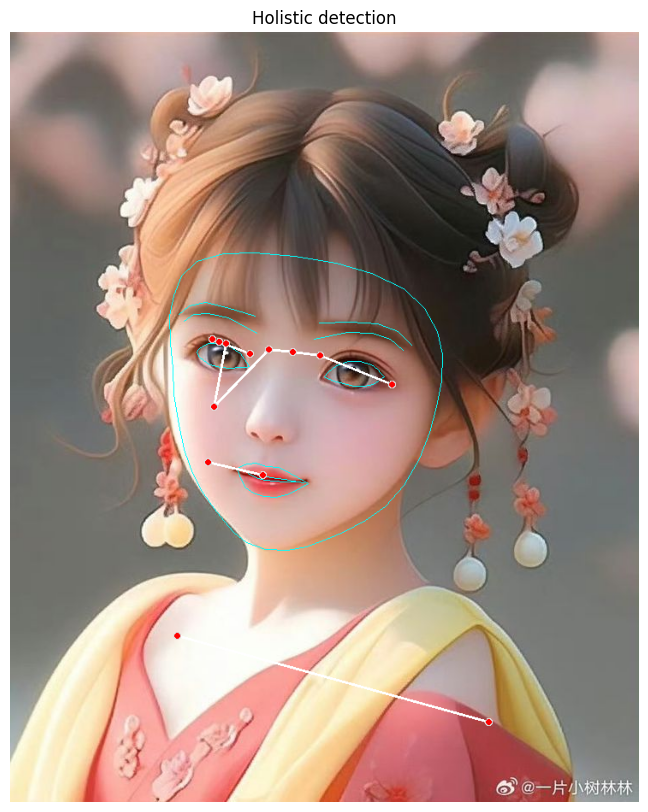

True

In [10]:
image_uploaded = files.upload()
if not image_uploaded:
    raise RuntimeError("画像がアップロードされていない。")
image_path = next(iter(image_uploaded.keys()))

image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise OSError(f"画像を開けない: {image_path}")

with create_holistic_landmarker(vision.RunningMode.IMAGE) as landmarker:
    result = landmarker.detect(bgr_to_mp_image(image_bgr))

annotated = annotate_holistic(image_bgr, result)
print(detection_summary(result))
show_bgr(annotated, "Holistic detection")
cv2.imwrite("annotated_image.png", annotated)


## 8. Colab上のWebカメラから静止画を撮影


In [12]:
from IPython.display import Javascript, display
from base64 import b64decode
from google.colab.output import eval_js


def take_photo(filename="photo.jpg", quality=0.8):
    js = Javascript(r'''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js(f"takePhoto({quality})")
    binary = b64decode(data.split(",")[1])
    with open(filename, "wb") as file:
        file.write(binary)
    return filename

filename = take_photo()
print("Saved:", filename)


<IPython.core.display.Javascript object>

Saved: photo.jpg


## 9. 撮影した静止画を検出


{'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


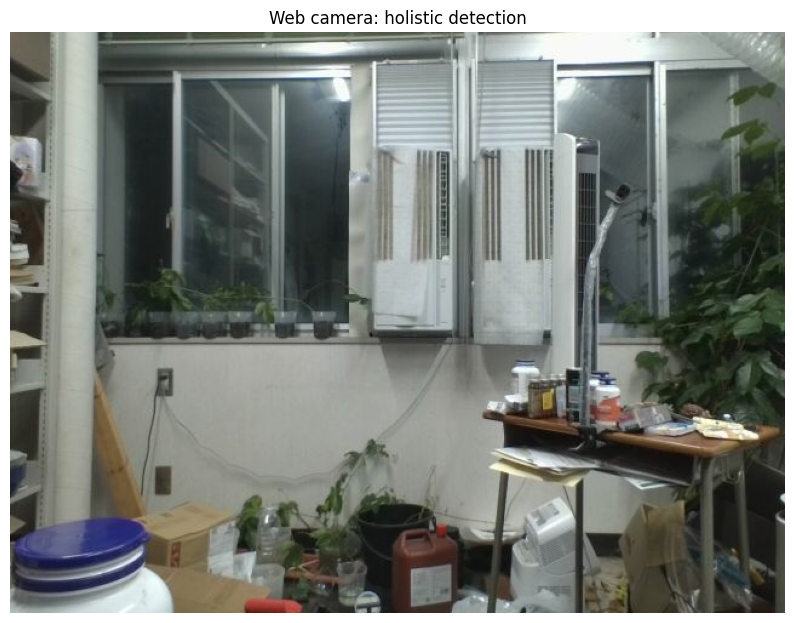

In [13]:
image_bgr = cv2.imread(filename)
if image_bgr is None:
    raise OSError(f"画像を開けない: {filename}")

with create_holistic_landmarker(vision.RunningMode.IMAGE) as landmarker:
    result = landmarker.detect(bgr_to_mp_image(image_bgr))

annotated = annotate_holistic(image_bgr, result)
print(detection_summary(result))
show_bgr(annotated, "Web camera: holistic detection")


## 10. Colab上のWebカメラから動画を録画


In [14]:
from IPython.display import HTML, Javascript, display
from base64 import b64decode
from google.colab import output

RECORD_VIDEO = r'''
const sleep = time => new Promise(resolve => setTimeout(resolve, time));
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader();
  reader.onloadend = e => resolve(e.srcElement.result);
  reader.readAsDataURL(blob);
});

var recordVideo = time => new Promise(async resolve => {
  const videoStream = await navigator.mediaDevices.getUserMedia({video: true, audio: false});
  const videoElement = document.createElement('video');
  videoElement.srcObject = videoStream;
  videoElement.play();
  document.body.appendChild(videoElement);

  const message = document.createElement('p');
  message.textContent = 'キャプチャ開始前...';
  document.body.appendChild(message);

  const button = document.createElement('button');
  button.textContent = 'キャプチャを開始';
  document.body.appendChild(button);

  await new Promise(resolveButton => button.onclick = resolveButton);
  message.textContent = 'キャプチャ中...';

  const recorder = new MediaRecorder(videoStream);
  const chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();

  await sleep(time);
  recorder.onstop = async () => {
    const blob = new Blob(chunks, {type: 'video/webm'});
    resolve(await b2text(blob));
    videoElement.pause();
    videoElement.srcObject = null;
    videoStream.getTracks().forEach(track => track.stop());
    videoElement.remove();
    message.remove();
    button.remove();
  };
  recorder.stop();
});
'''


def record_video(sec, filename="recorded_video.webm"):
    display(HTML("<h3>録画を開始する</h3>"))
    display(Javascript(RECORD_VIDEO))
    video_data = output.eval_js(f"recordVideo({int(sec * 1000)})")
    video_binary = b64decode(video_data.split(",")[1])
    with open(filename, "wb") as file:
        file.write(video_binary)
    return filename

record_seconds = 10
video_filename = record_video(record_seconds)
print("Saved:", video_filename)


<IPython.core.display.Javascript object>

Saved: recorded_video.webm


## 11. WebMをMP4へ変換


In [15]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg

from pathlib import Path
from IPython.display import Video, display

input_file = Path(video_filename)
output_file = input_file.with_suffix(".mp4")

!ffmpeg -y -loglevel error -i "{input_file}" -c:v libx264 -pix_fmt yuv420p "{output_file}"

display(Video(str(output_file), embed=True))
video_path = str(output_file)
print("Video path:", video_path)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Video path: recorded_video.mp4


## 12. 録画動画を検出・表示


Total frames: 9998
FPS: 1000.0
Target frames (0-based): [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Frame 0: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


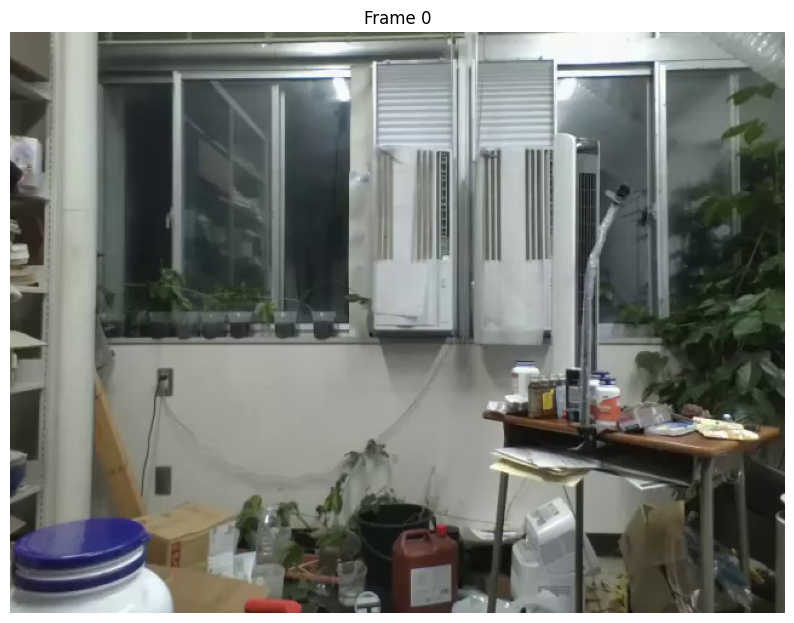

Frame 10: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


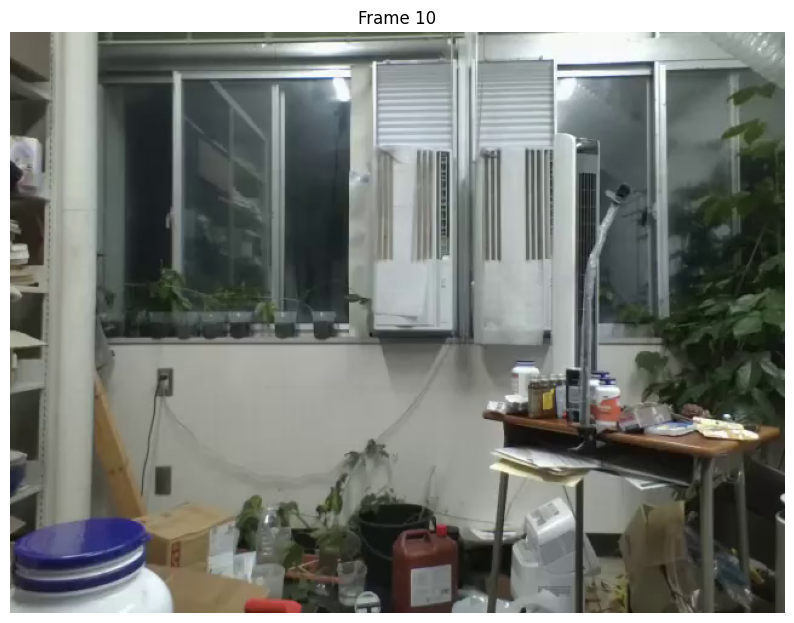

Frame 20: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


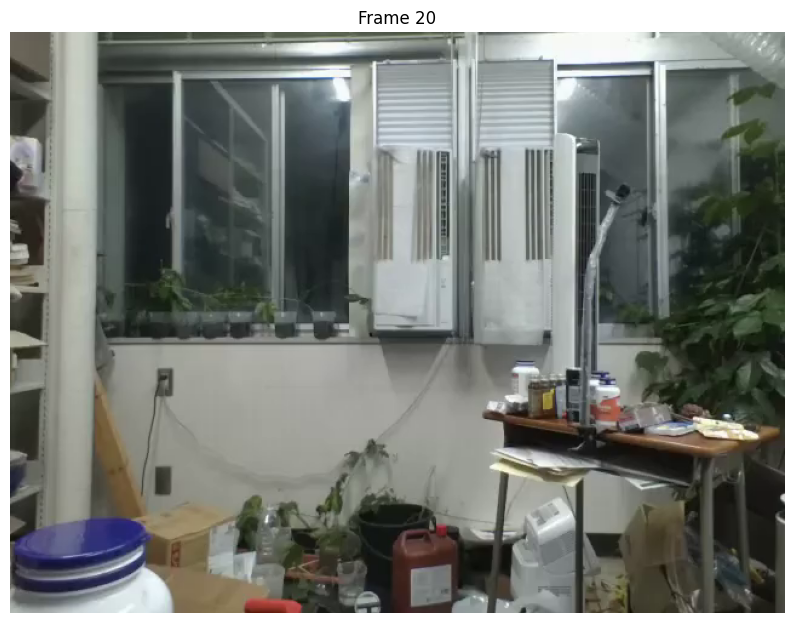

Frame 30: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


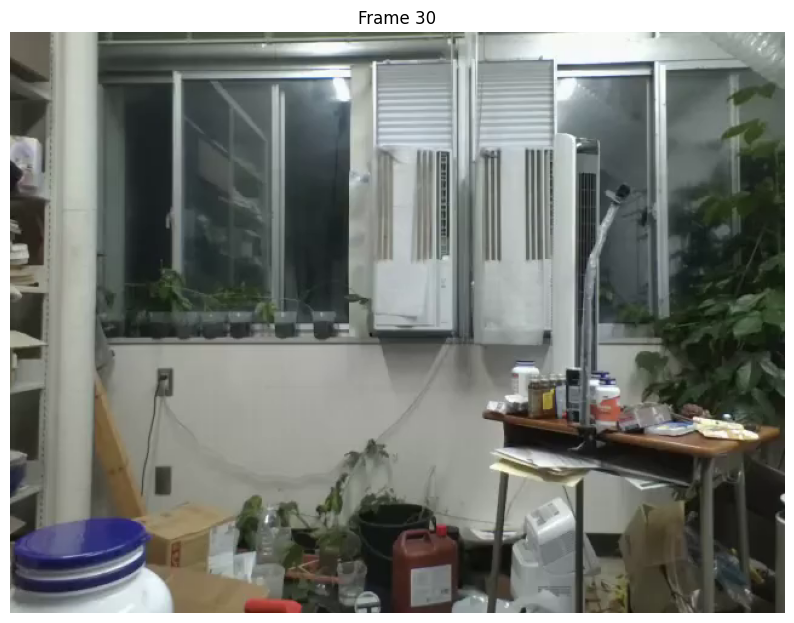

Frame 40: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


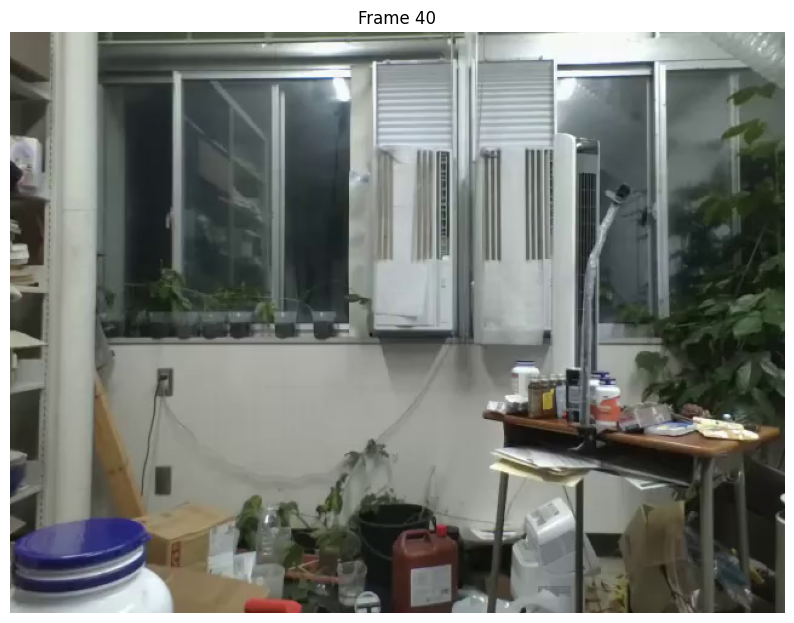

Frame 50: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


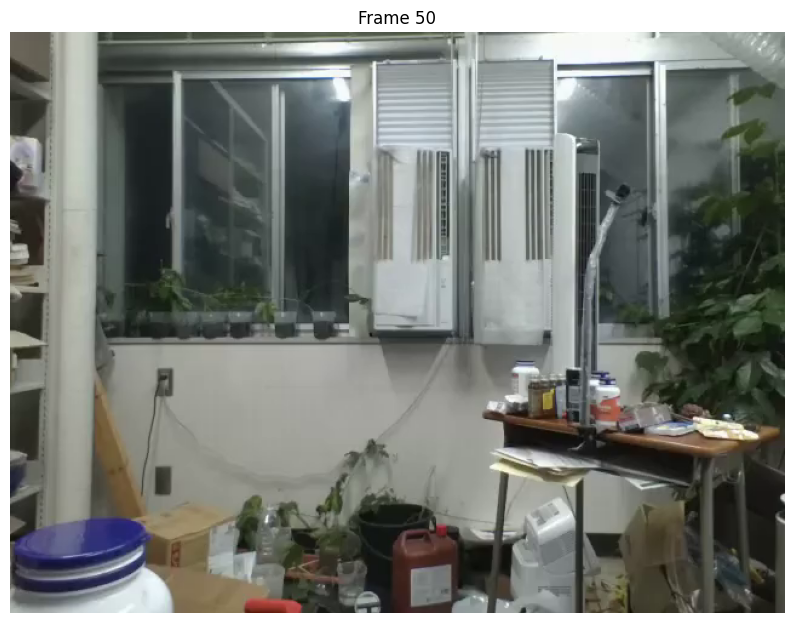

Frame 60: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


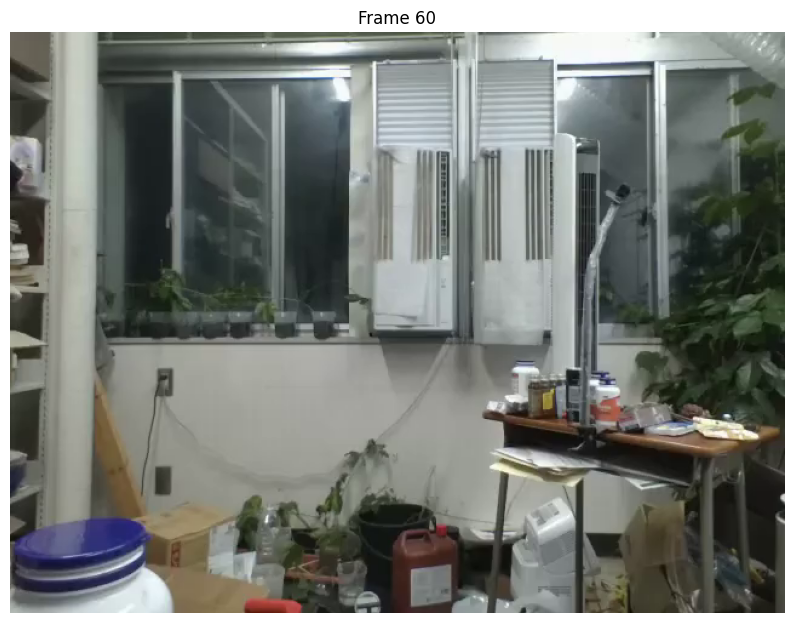

Frame 70: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


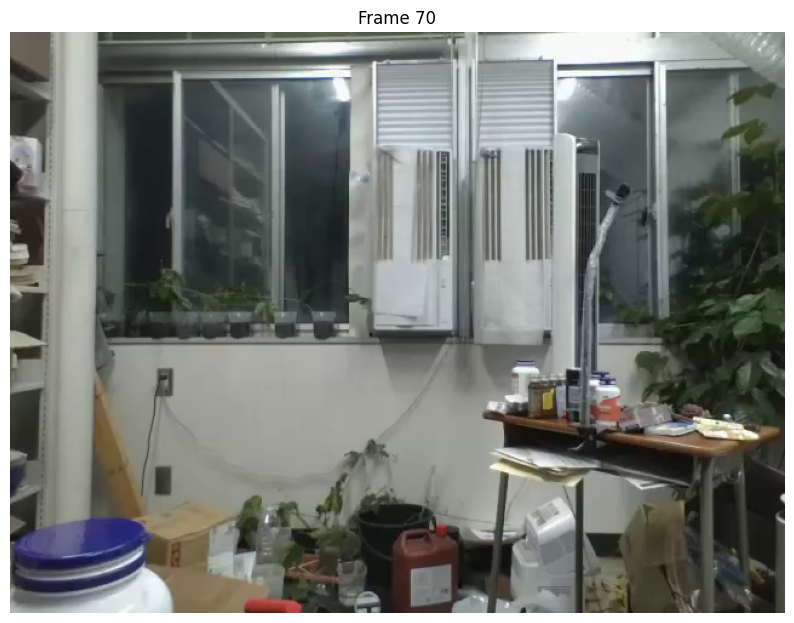

Frame 80: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


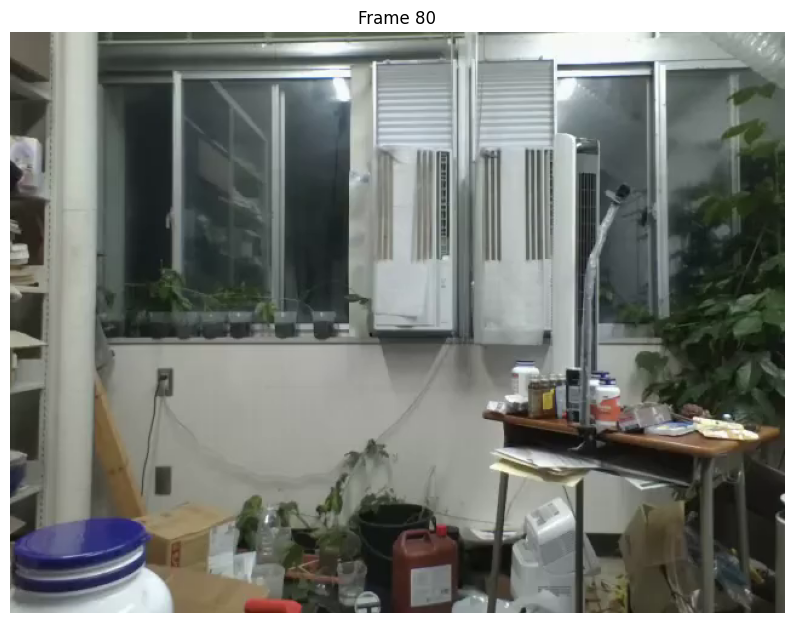

Frame 90: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


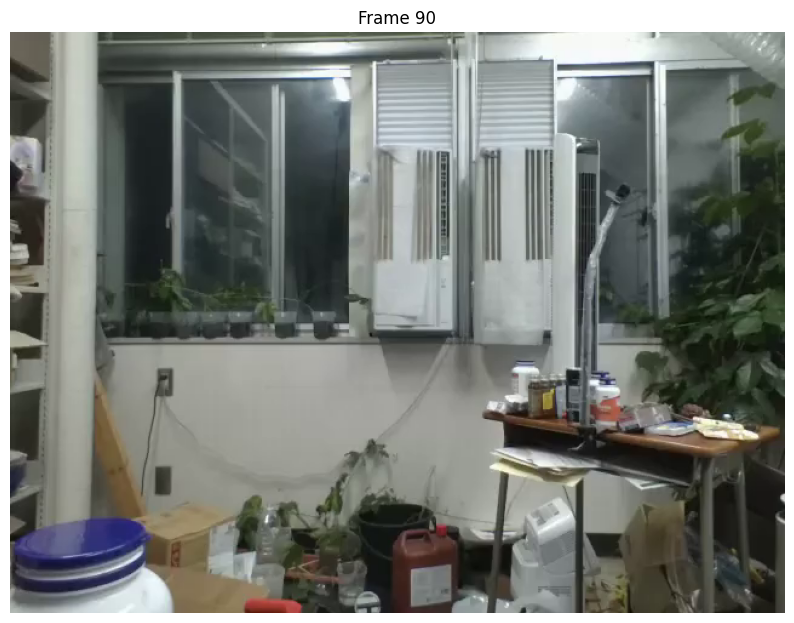

Frame 100: {'pose': False, 'face': False, 'left_hand': False, 'right_hand': False}


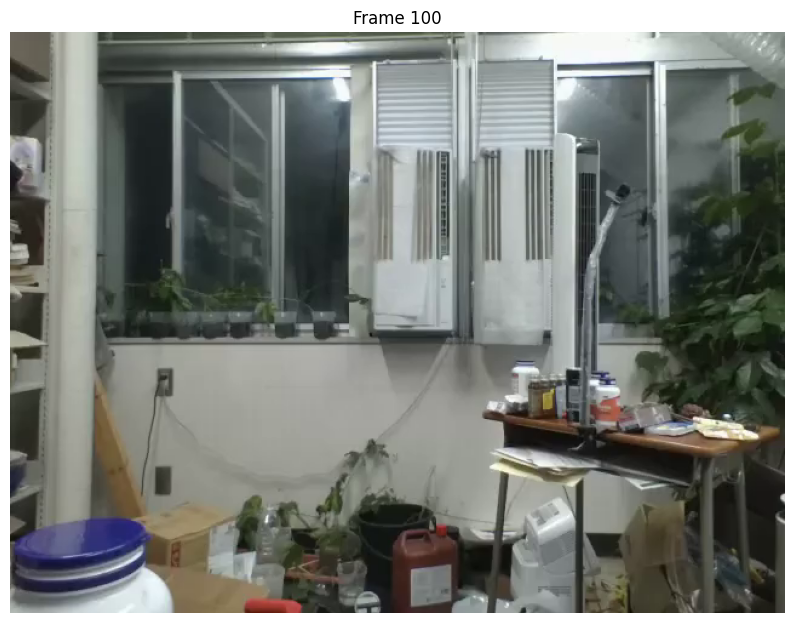

In [16]:
show_selected_video_frames(
    video_path,
    frame_indices=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
)


## 主な移行点

- `mp.solutions.*` は使用しない
- `HolisticLandmarkerOptions` と `HolisticLandmarker.create_from_options()` を使用する
- 静止画は `detect()`、動画は `detect_for_video()` を使用する
- 動画ではフレームごとに単調増加する `timestamp_ms` を渡す
- 結果のランドマークは旧APIの `landmarks.landmark` ではなく、直接 `list` として扱う
